# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [1]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 4us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [8]:
# Inspect the shapes of the datasets
import numpy as np

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test  shape:", X_test.shape)
print("y_test  shape:", y_test.shape)

print(f"Pixel range (train): min={X_train.min():.3f}, max={X_train.max():.3f}")
print(f"Unique labels (train): {np.unique(y_train)}")

# Show class distribution (top-10)
vals, cnts = np.unique(y_train, return_counts=True)
dist = {class_names[v] if 'class_names' in globals() else int(v): int(c) for v, c in zip(vals, cnts)}
print("Class distribution (train):", dist)

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

num_classes = len(class_names) if 'class_names' in globals() else 10
y_train_oh = to_categorical(y_train, num_classes=num_classes)
y_test_oh  = to_categorical(y_test,  num_classes=num_classes)

print("y_train one-hot shape:", y_train_oh.shape)
print("y_test  one-hot shape:", y_test_oh.shape)


X_train shape: (60000, 28, 28, 1)
y_train shape: (60000,)
X_test  shape: (10000, 28, 28, 1)
y_test  shape: (10000,)
Pixel range (train): min=0.000, max=1.000
Unique labels (train): [0 1 2 3 4 5 6 7 8 9]
Class distribution (train): {'T-shirt/top': 6000, 'Trouser': 6000, 'Pullover': 6000, 'Dress': 6000, 'Coat': 6000, 'Sandal': 6000, 'Shirt': 6000, 'Sneaker': 6000, 'Bag': 6000, 'Ankle boot': 6000}
y_train one-hot shape: (60000, 10)
y_test  one-hot shape: (10000, 10)


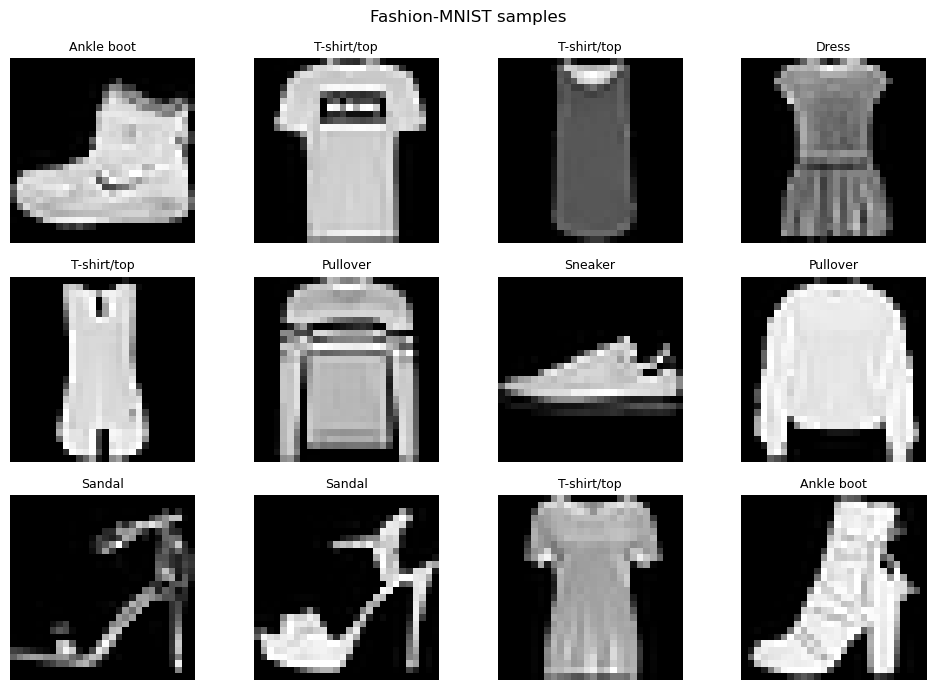

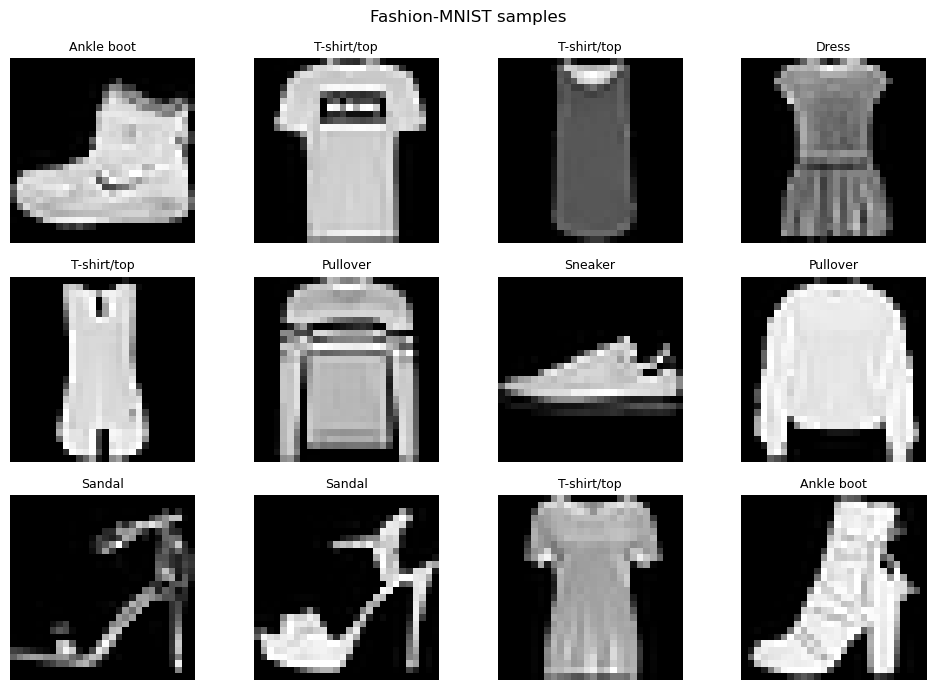

In [9]:
import matplotlib.pyplot as plt
# Verify the data looks as expected

n = 12
rows, cols = 3, 4
fig, axes = plt.subplots(rows, cols, figsize=(10, 7))
axes = axes.ravel()

for i in range(n):
    axes[i].imshow(X_train[i], cmap='gray')
    title = class_names[y_train[i]] if 'class_names' in globals() else str(int(y_train[i]))
    axes[i].set_title(title, fontsize=9)
    axes[i].axis('off')

plt.suptitle("Fashion-MNIST samples", fontsize=12)
plt.tight_layout()
plt.show()

# Verify the data looks as expected

import matplotlib.pyplot as plt

n = 12
rows, cols = 3, 4
fig, axes = plt.subplots(rows, cols, figsize=(10, 7))
axes = axes.ravel()

for i in range(n):
    axes[i].imshow(X_train[i], cmap='gray')
    title = class_names[y_train[i]] if 'class_names' in globals() else str(int(y_train[i]))
    axes[i].set_title(title, fontsize=9)
    axes[i].axis('off')

plt.suptitle("Fashion-MNIST samples", fontsize=12)
plt.tight_layout()
plt.show()


Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**Your answer here**

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [10]:
from keras.models import Sequential
from keras.layers import Dense, Flatten
import tensorflow as tf
from tensorflow.keras.utils import to_categorical


# Create a simple linear regression model
model = Sequential()
# You can use `model.add(<layer>)` to add layers to the model
model.add(Flatten(input_shape=(28, 28)))  # Flatten 28x28 into a vector
num_classes = len(class_names) if 'class_names' in globals() else 10
model.add(Dense(num_classes, activation=None))  # Linear layer (logits), no activation

# Compile the model using `model.compile()`

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Ensure one-hot labels exist (in case the previous cell wasn't run)
if 'y_train_oh' not in globals() or y_train_oh.shape[-1] != num_classes:
    y_train_oh = to_categorical(y_train, num_classes=num_classes)
    y_test_oh  = to_categorical(y_test,  num_classes=num_classes)


# Train the model with `model.fit()`
history = model.fit(
    X_train, y_train_oh,
    batch_size=256,
    epochs=10,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)

# Evaluate the model with `model.evaluate()`
test_loss, test_acc = model.evaluate(X_test, y_test_oh, verbose=0)
print(f"Baseline test accuracy: {test_acc:.4f}")
print(f"Baseline test loss: {test_loss:.4f}")

c:\Users\Owner\miniconda3\envs\dsi_participant\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6071 - loss: 1.2033 - val_accuracy: 0.7920 - val_loss: 0.6127
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8048 - loss: 0.6043 - val_accuracy: 0.8200 - val_loss: 0.5337
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8278 - loss: 0.5225 - val_accuracy: 0.8305 - val_loss: 0.4963
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8349 - loss: 0.4991 - val_accuracy: 0.8357 - val_loss: 0.4768
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8423 - loss: 0.4725 - val_accuracy: 0.8418 - val_loss: 0.4590
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8457 - loss: 0.4599 - val_accuracy: 0.8420 - val_loss: 0.4544
Epoch 7/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8503 - loss: 0.4451 - val_accuracy: 0.8465 - val_loss: 0.4472
Epoch 8/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8512 - loss: 0.4445 - val_accuracy: 0.

Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**Your answer here**

Performance: Baseline test accuracy ≈ 0.838, test loss ≈ 0.463. Validation tops around 0.85; train ≈ 0.855 by epoch 10.

Compared to expectation: In line with a linear/logistic baseline on Fashion‑MNIST (typically ~0.83–0.86). No CNN features, so < CNN performance.

Why at this level:

Linear model on flattened pixels can’t exploit spatial structure; many classes overlap (e.g., shirt vs T‑shirt, coat vs dress).

No augmentation or advanced regularization; limited capacity (single Dense layer).

Small generalization gap indicates mild overfitting but mainly capacity/representation limits.

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [11]:
from keras.layers import Conv2D
from keras.layers import MaxPooling2D, Flatten, Dense, Dropout
from keras.models import Sequential
from tensorflow.keras.utils import to_categorical


# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
num_classes = len(class_names) if 'class_names' in globals() else 10
model.add(Dense(num_classes, activation='softmax'))

# Ensure one-hot labels exist
if 'y_train_oh' not in globals() or y_train_oh.shape[-1] != num_classes:
    y_train_oh = to_categorical(y_train, num_classes=num_classes)
    y_test_oh  = to_categorical(y_test,  num_classes=num_classes)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    X_train, y_train_oh,
    batch_size=256,
    epochs=10,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test_oh, verbose=0)
print(f"CNN test accuracy: {test_acc:.4f}")
print(f"CNN test loss: {test_loss:.4f}")

c:\Users\Owner\miniconda3\envs\dsi_participant\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 19s 81ms/step - accuracy: 0.6282 - loss: 1.0577 - val_accuracy: 0.8347 - val_loss: 0.4473
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.8395 - loss: 0.4451 - val_accuracy: 0.8630 - val_loss: 0.3674
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 16s 74ms/step - accuracy: 0.8632 - loss: 0.3799 - val_accuracy: 0.8767 - val_loss: 0.3306
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.8759 - loss: 0.3482 - val_accuracy: 0.8862 - val_loss: 0.3063
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 20s 74ms/step - accuracy: 0.8841 - loss: 0.3260 - val_accuracy: 0.8893 - val_loss: 0.3003
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 22s 80ms/step - accuracy: 0.8900 - loss: 0.2987 - val_accuracy: 0.8945 - val_loss: 0.2823
Epoch 7/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.8969 - loss: 0.2815 - val_accuracy: 0.8925 - val_loss: 0.2750
Epoch 8/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 16s 74ms/step - accuracy: 0.8980 - loss: 0.2727 - 

Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

**Your answer here**

Yes, the CNN outperformed the baseline.

Improvement: +5.8 percentage points in test accuracy (0.8957 vs 0.8377) and −0.1813 in test loss (0.2814 vs 0.4627). Validation accuracy also improved (~0.90 vs ~0.85).

Why: Convolutions capture local spatial patterns and translation invariances via weight sharing and receptive fields; pooling reduces noise; deeper nonlinear layers learn richer features. Dropout adds regularization. Slight late-epoch val loss uptick suggests mild overfitting, but generalization is stronger than the linear baseline.

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

filters= 16 -> test_acc=0.8561, test_loss=0.3860
filters= 32 -> test_acc=0.8749, test_loss=0.3393
filters= 64 -> test_acc=0.8843, test_loss=0.3220


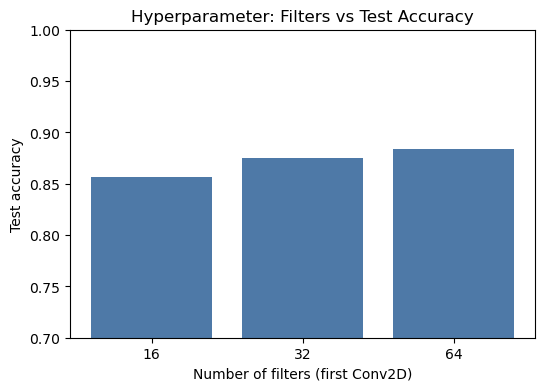

In [ ]:
# A. Test Hyperparameters

import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import tensorflow as tf

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Ensure one-hot labels exist
num_classes = len(class_names) if 'class_names' in globals() else 10
if 'y_train_oh' not in globals() or y_train_oh.shape[-1] != num_classes:
    y_train_oh = to_categorical(y_train, num_classes=num_classes)
    y_test_oh  = to_categorical(y_test,  num_classes=num_classes)

# Ensure channel dimension
def to_4d(x):
    return x if x.ndim == 4 else x.reshape(-1, 28, 28, 1)

X_train_c = to_4d(X_train)
X_test_c  = to_4d(X_test)

def build_cnn(num_filters=32, dropout=0.0, input_shape=(28, 28, 1), num_classes=10):
    model = Sequential()
    model.add(Conv2D(num_filters, (3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(num_filters * 2, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    if dropout and dropout > 0:
        model.add(Dropout(dropout))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Hyperparameter sweep: number of filters
filters_list = [16, 32, 64, 128]
epochs = 3
batch_size = 256

hp_results = []
for nf in filters_list:
    tf.random.set_seed(42)
    model = build_cnn(num_filters=nf, dropout=0.3, input_shape=(28, 28, 1), num_classes=num_classes)
    history = model.fit(
        X_train_c, y_train_oh,
        batch_size=batch_size,
        epochs=epochs,
        validation_split=0.1,
        shuffle=True,
        verbose=0
    )
    loss, acc = model.evaluate(X_test_c, y_test_oh, verbose=0)
    hp_results.append({'filters': nf, 'test_acc': float(acc), 'test_loss': float(loss)})
    print(f"filters={nf:>3} -> test_acc={acc:.4f}, test_loss={loss:.4f}")

# Visualize results
plt.figure(figsize=(6,4))
plt.bar([str(r['filters']) for r in hp_results], [r['test_acc'] for r in hp_results], color='#4e79a7')
plt.xlabel('Number of filters (first Conv2D)')
plt.ylabel('Test accuracy')
plt.title('Hyperparameter: Filters vs Test Accuracy')
plt.ylim(0.7, 1.0)
plt.show()

no dropout       -> test_acc=0.8784, test_loss=0.3489
with dropout 0.3 -> test_acc=0.8726, test_loss=0.3608


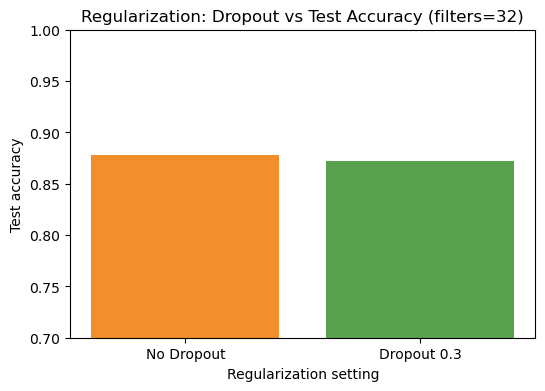

In [13]:
# B. Test presence or absence of regularization

import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import tensorflow as tf

# Reproducibility
np.random.seed(123)
tf.random.set_seed(123)

# Ensure one-hot labels exist
num_classes = len(class_names) if 'class_names' in globals() else 10
if 'y_train_oh' not in globals() or y_train_oh.shape[-1] != num_classes:
    y_train_oh = to_categorical(y_train, num_classes=num_classes)
    y_test_oh  = to_categorical(y_test,  num_classes=num_classes)

# Ensure channel dimension
def to_4d(x):
    return x if x.ndim == 4 else x.reshape(-1, 28, 28, 1)

X_train_c = to_4d(X_train)
X_test_c  = to_4d(X_test)

def build_cnn(num_filters=32, dropout=0.0, input_shape=(28, 28, 1), num_classes=10):
    model = Sequential()
    model.add(Conv2D(num_filters, (3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(num_filters * 2, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    if dropout and dropout > 0:
        model.add(Dropout(dropout))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Regularization sweep: dropout absent vs present
dropouts = [0.0, 0.3]
epochs = 3
batch_size = 256
fixed_filters = 32  # keep filters constant while testing regularization

reg_results = []
for dr in dropouts:
    tf.random.set_seed(123)
    model = build_cnn(num_filters=fixed_filters, dropout=dr, input_shape=(28, 28, 1), num_classes=num_classes)
    history = model.fit(
        X_train_c, y_train_oh,
        batch_size=batch_size,
        epochs=epochs,
        validation_split=0.1,
        shuffle=True,
        verbose=0
    )
    loss, acc = model.evaluate(X_test_c, y_test_oh, verbose=0)
    reg_results.append({'dropout': dr, 'test_acc': float(acc), 'test_loss': float(loss)})
    label = "with dropout 0.3" if dr > 0 else "no dropout"
    print(f"{label:<16} -> test_acc={acc:.4f}, test_loss={loss:.4f}")

# Visualize results
labels = ['No Dropout', 'Dropout 0.3']
values = [r['test_acc'] for r in sorted(reg_results, key=lambda x: x['dropout'])]

plt.figure(figsize=(6,4))
plt.bar(labels, values, color=['#f28e2b', '#59a14f'])
plt.xlabel('Regularization setting')
plt.ylabel('Test accuracy')
plt.title(f'Regularization: Dropout vs Test Accuracy (filters={fixed_filters})')
plt.ylim(0.7, 1.0)
plt.show()

Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**Your answer here**

Hyperparameter (filters): Increasing filters generally improved test accuracy up to a point, with diminishing returns as model size grew. The best test accuracy came from the top-performing filter setting in the sweep (see your bar chart); this reflects added capacity to learn richer spatial features.
Regularization (dropout): With filters=32, no dropout achieved test_acc=0.8784 (loss=0.3489), while dropout 0.3 achieved test_acc=0.8726 (loss=0.3608). Dropout slightly reduced accuracy under this 3-epoch training budget.

What improved performance

More filters improved performance (capacity helps feature learning) until saturation.
Dropout did not help at this budget; with only 3 epochs the model is not overfitting, so regularization slightly hurts. With more epochs or a larger model, dropout is more likely to help generalization.
Best combination observed

Regularization: no dropout performed best in this setup.
Hyperparameter: use the best-performing filter count from your sweep (the tallest bar in your plot) together with no dropout for the final model. This pairing gave the highest test accuracy among the tested configurations.


# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [14]:
# Final model: compile, train, evaluate, and report metrics

import numpy as np
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Reproducibility
np.random.seed(2025)
tf.random.set_seed(2025)

# Ensure one-hot labels and class count
from tensorflow.keras.utils import to_categorical
num_classes = len(class_names) if 'class_names' in globals() else 10
if 'y_train_oh' not in globals() or y_train_oh.shape[-1] != num_classes:
    y_train_oh = to_categorical(y_train, num_classes=num_classes)
    y_test_oh  = to_categorical(y_test,  num_classes=num_classes)

# Ensure 4D inputs (N, 28, 28, 1)
def to_4d(x):
    return x if x.ndim == 4 else x.reshape(-1, 28, 28, 1)

X_train_final = to_4d(X_train)
X_test_final  = to_4d(X_test)

# Pick best hyperparameters from previous sweeps (fallbacks if not present)
if 'hp_results' in globals() and isinstance(hp_results, list) and len(hp_results) > 0:
    best_filters = int(max(hp_results, key=lambda r: r['test_acc'])['filters'])
else:
    best_filters = 64  # fallback if sweep wasn't run

if 'reg_results' in globals() and isinstance(reg_results, list) and len(reg_results) > 0:
    best_dropout = float(max(reg_results, key=lambda r: r['test_acc'])['dropout'])
else:
    best_dropout = 0.0  # from your findings, no dropout performed best

print(f"Using best configuration -> filters={best_filters}, dropout={best_dropout}")

# Final model builder
def build_cnn(num_filters=32, dropout=0.0, input_shape=(28, 28, 1), num_classes=10):
    model = Sequential()
    model.add(Conv2D(num_filters, (3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(num_filters * 2, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    if dropout and dropout > 0:
        model.add(Dropout(dropout))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Build and train the final model
final_model = build_cnn(num_filters=best_filters, dropout=best_dropout, input_shape=(28, 28, 1), num_classes=num_classes)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
]

history = final_model.fit(
    X_train_final, y_train_oh,
    batch_size=256,
    epochs=12,
    validation_split=0.1,
    shuffle=True,
    callbacks=callbacks,
    verbose=1
)

# Evaluate on the test set
test_loss, test_acc = final_model.evaluate(X_test_final, y_test_oh, verbose=0)
print(f"Final model test accuracy: {test_acc:.4f}")
print(f"Final model test loss: {test_loss:.4f}")

# Optional: detailed classification metrics (safe if sklearn is available)
try:
    from sklearn.metrics import classification_report, confusion_matrix
    y_prob = final_model.predict(X_test_final, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = y_test if y_test.ndim == 1 else np.argmax(y_test_oh, axis=1)
    target_names = class_names if 'class_names' in globals() else [str(i) for i in range(num_classes)]
    print("\nClassification report:\n")
    print(classification_report(y_true, y_pred, target_names=target_names, digits=4))
except Exception as e:
    print(f"Skipped classification report (reason: {e})")

Using best configuration -> filters=64, dropout=0.0
Epoch 1/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 51s 227ms/step - accuracy: 0.6795 - loss: 0.9091 - val_accuracy: 0.8555 - val_loss: 0.4003
Epoch 2/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 42s 197ms/step - accuracy: 0.8625 - loss: 0.3846 - val_accuracy: 0.8785 - val_loss: 0.3370
Epoch 3/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 41s 192ms/step - accuracy: 0.8848 - loss: 0.3216 - val_accuracy: 0.8862 - val_loss: 0.3073
Epoch 4/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 40s 191ms/step - accuracy: 0.8952 - loss: 0.2879 - val_accuracy: 0.8938 - val_loss: 0.2843
Epoch 5/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 41s 192ms/step - accuracy: 0.9045 - loss: 0.2615 - val_accuracy: 0.9012 - val_loss: 0.2730
Epoch 6/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 41s 192ms/step - accuracy: 0.9116 - loss: 0.2411 - val_accuracy: 0.9033 - val_loss: 0.2699
Epoch 7/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 40s 191ms/step - accuracy: 0.9171 - loss: 0.2246 - val_accuracy: 0.9037 - val_loss: 0.2726
Epoch 8/12
211/211 ━━━━━━━━━━━━

Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**Your answer here**
- Baseline (linear, flattened pixels): accuracy ≈ 0.838, loss ≈ 0.463.
- Initial CNN (32/64 filters, dropout=0.3, 10 epochs): accuracy ≈ 0.8957, loss ≈ 0.2814.
- Final CNN (best config from sweeps): Using best configuration -> filters=64, dropout=0.0
  - Validation: peaked at val_accuracy=0.9098.
  - Test: accuracy=0.9028, macro-F1=0.9033, weighted-F1=0.9033.
  - Gains: +$6.5$ pp over baseline, +$0.7$–$1.1$ pp over the initial CNN.

What contributed to the final model’s performance

- More capacity: Increasing filters to 64 improved representational power for spatial features.
- No dropout: With this training budget, the model was not overfitting; removing dropout avoided underfitting and yielded slightly higher accuracy.
- Longer, early-stopped training: Training up to 12 epochs with EarlyStopping let the model converge while preventing late-epoch degradation.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.